# 01 — CIFAR-10 Data Exploration & Preprocessing

This notebook lets you:
1. Download CIFAR-10 locally
2. Visualize raw images
3. Understand and apply the preprocessing pipeline
4. See what the model will actually receive during training

**No GPU needed — run this locally.**

## 1. Imports

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


## 2. Download CIFAR-10 (raw, no preprocessing)

Downloads ~170 MB into `./data/`. Only happens once — subsequent runs use the cached version.

In [3]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Raw dataset — ToTensor only converts [0,255] int -> [0,1] float, no other changes
raw_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

print(f"Number of training images : {len(raw_dataset)}")
print(f"Image shape (C, H, W)     : {raw_dataset[0][0].shape}")
print(f"Pixel range               : [{raw_dataset[0][0].min():.2f}, {raw_dataset[0][0].max():.2f}]")

100%|██████████| 170M/170M [00:06<00:00, 25.2MB/s] 


Number of training images : 50000
Image shape (C, H, W)     : torch.Size([3, 32, 32])
Pixel range               : [0.00, 1.00]


## 3. Visualize raw images

Let's look at one image per class to understand what the model will learn to generate.

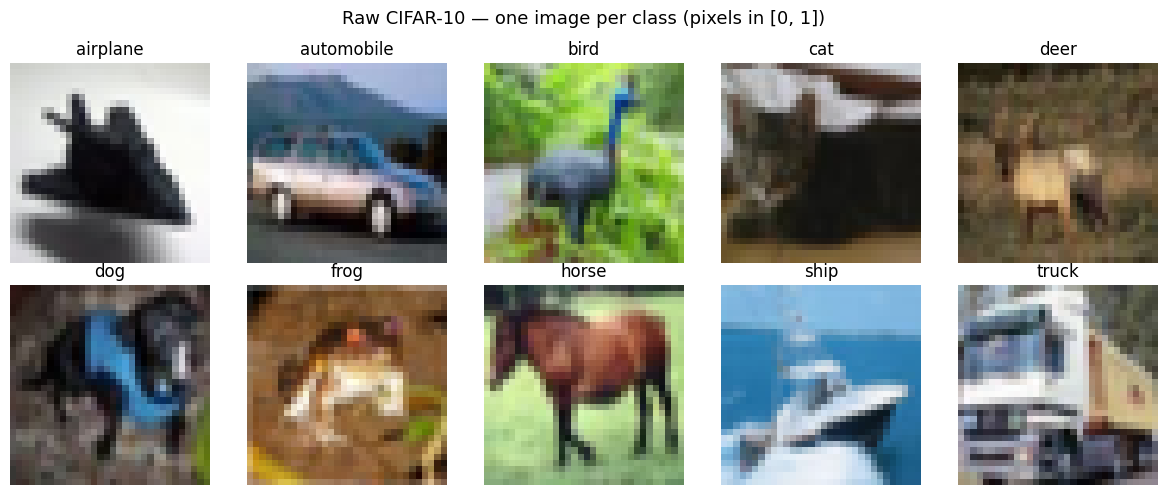

In [23]:
# Pick one example per class
examples = {}
for img, label in raw_dataset:
    if label not in examples:
        examples[label] = img
    if len(examples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Raw CIFAR-10 — one image per class (pixels in [0, 1])", fontsize=13)
for i, ax in enumerate(axes.flat):
    img = examples[i].permute(1, 2, 0)  # (C,H,W) -> (H,W,C) for matplotlib
    ax.imshow(img)
    ax.set_title(CLASSES[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Apply the training preprocessing

Two steps:
1. **Random horizontal flip** — augmentation, doubles effective dataset size
2. **Normalize to [-1, 1]** — centers data around 0 to match the Gaussian noise distribution

The formula: `pixel_out = (pixel_in - 0.5) / 0.5` which maps [0,1] -> [-1,1]

In [24]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),   # mean per channel
                         (0.5, 0.5, 0.5))   # std per channel
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=False,
    transform=train_transform
)

# Check the pixel range after normalization
sample_img, sample_label = train_dataset[0]
print(f"After normalization:")
print(f"  Shape  : {sample_img.shape}")
print(f"  Min    : {sample_img.min():.4f}")
print(f"  Max    : {sample_img.max():.4f}")
print(f"  Mean   : {sample_img.mean():.4f}")
print(f"  Label  : {CLASSES[sample_label]}")

After normalization:
  Shape  : torch.Size([3, 32, 32])
  Min    : -1.0000
  Max    : 1.0000
  Mean   : -0.1886
  Label  : frog


## 5. Visualize: before vs after normalization

The image looks identical visually — normalization only changes the numeric range, not the content. But notice how the values shift from [0,1] to [-1,1].

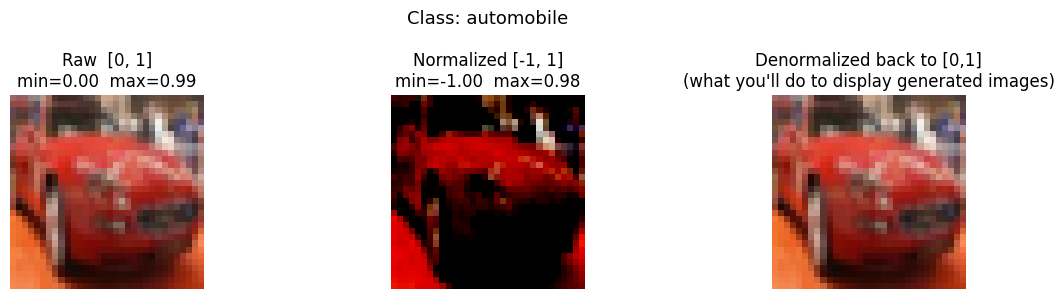

In [32]:
def denormalize(img_tensor):
    """Map [-1, 1] back to [0, 1] for visualization."""
    return (img_tensor + 1) / 2

idx = np.random.randint(0,10)  # pick any index to inspect
raw_img, label = raw_dataset[idx]
norm_img, _    = train_dataset[idx]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
fig.suptitle(f"Class: {CLASSES[label]}", fontsize=13)

axes[0].imshow(raw_img.permute(1, 2, 0).numpy())
axes[0].set_title(f"Raw  [0, 1]\nmin={raw_img.min():.2f}  max={raw_img.max():.2f}")
axes[0].axis('off')

axes[1].imshow(norm_img.permute(1, 2, 0).numpy(), vmin=-1, vmax=1, cmap='RdBu_r')
axes[1].set_title(f"Normalized [-1, 1]\nmin={norm_img.min():.2f}  max={norm_img.max():.2f}")
axes[1].axis('off')

axes[2].imshow(denormalize(norm_img).permute(1, 2, 0).numpy())
axes[2].set_title("Denormalized back to [0,1]\n(what you'll do to display generated images)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6. The DataLoader — what training actually sees

The DataLoader batches images together. Each training step gets a tensor of shape `[batch_size, 3, 32, 32]`. The labels come with it but we mostly ignore them (unconditional generation).

In [34]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,       # parallel workers loading data while GPU trains
    pin_memory=True,     # faster GPU transfer (no-op if on CPU)
    drop_last=True       # discard last incomplete batch for cleaner training
)

# Grab a single batch and inspect it
batch_imgs, batch_labels = next(iter(train_loader))

print(f"Batch shape  : {batch_imgs.shape}")     # [128, 3, 32, 32]
print(f"Labels shape : {batch_labels.shape}")   # [128]
print(f"Pixel range  : [{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]")
print(f"Num batches per epoch: {len(train_loader)}")  # 50000 // 128 = 390

Batch shape  : torch.Size([128, 3, 32, 32])
Labels shape : torch.Size([128])
Pixel range  : [-1.00, 1.00]
Num batches per epoch: 390


## 7. Visualize a full batch grid

This is exactly what the model sees at each training step.

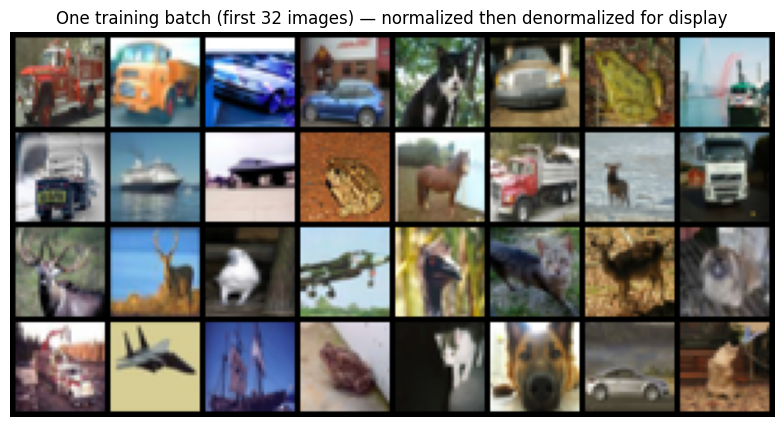

In [38]:
# Show first 32 images from the batch in a grid
grid = torchvision.utils.make_grid(
    denormalize(batch_imgs[:32]),
    nrow=8,
    padding=2
)
plt.figure(figsize=(14, 5))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("One training batch (first 32 images) — normalized then denormalized for display")
plt.axis('off')
plt.show()

## 8. Why does [-1, 1] matter? — Noise comparison

During CFM/DDPM training, we interpolate between real images and Gaussian noise N(0,1). If data lives in [-1,1] and noise lives in roughly [-3,3], the "middle" of the interpolation is well-balanced. Let's visualize this.

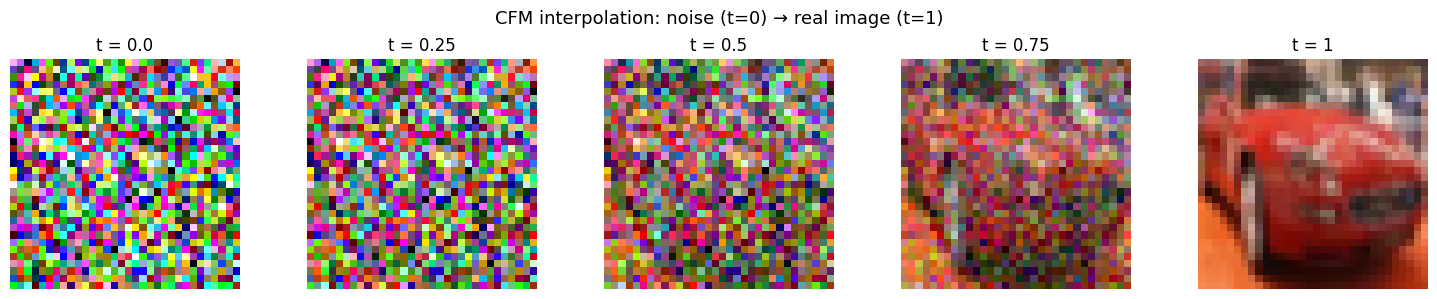

The velocity (what CFM learns to predict) = x1 - noise:
  Velocity range: [-4.14, 3.05]


In [65]:
torch.manual_seed(5)
noise = torch.randn(3, 32, 32)   # pure Gaussian noise, same shape as one image
x1 = norm_img                    # a real normalized image
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("CFM interpolation: noise (t=0) → real image (t=1)", fontsize=13)

for i, t in enumerate([0.0, 0.25, 0.5, 0.75, 1]):
    x_t = (1 - t) * noise + t * x1        # the interpolated image at time t
    display = denormalize(x_t).clamp(0, 1) # clamp for display only
    axes[i].imshow(display.permute(1, 2, 0).numpy())
    axes[i].set_title(f"t = {t}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("The velocity (what CFM learns to predict) = x1 - noise:")
velocity = x1 - noise
print(f"  Velocity range: [{velocity.min():.2f}, {velocity.max():.2f}]")

## DDPM Implementation - Ali


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange #pip install einops
from typing import List
import random
import math
from torchvision import datasets, transforms
from torch.utils.data import DataLoader 
from timm.utils import ModelEmaV3 #pip install timm 
from tqdm import tqdm #pip install tqdm
import matplotlib.pyplot as plt #pip install matplotlib
import torch.optim as optim
import numpy as np

In [14]:
class SinusoidalEmbeddings(nn.Module):
    def __init__(self, time_steps:int, embed_dim: int):
        super().__init__()
        position = torch.arange(time_steps).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,embed_dim,2).float() * -(math.log(10000.0) / embed_dim))
        embeddings = torch.zeros(time_steps, embed_dim, requires_grad=False)
        embeddings[:, 0::2] = torch.sin(position * div)
        embeddings[:, 1::2] = torch.cos(position * div)
        self.embeddings = embeddings
    
    def forward(self,x, t):
        embeds = self.embeddings[t].to(x.device)
        return embeds[:, :, None, None]



NameError: name 'nn' is not defined

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, C: int, num_groups: int, dropout_prob: float):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.gnorm1 = nn.GroupNorm(num_groups=num_groups, num_channels=C)
        self.gnorm2 = nn.GroupNorm(num_groups=num_groups, num_channels=C)
        self.conv1 = nn.Conv2d(C, C, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(C, C, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=dropout_prob, inplace=True)

    def forward(self, x, embeddings):
        x = x + embeddings[:, :x.shape[1], :, :]
        r = self.conv1(self.relu(self.gnorm1(x)))
        r = self.dropout(r)
        r = self.conv2(self.relu(self.gnorm2(r)))
        return r + x

: 

: 

In [ ]:
class Attention(nn.Module):
    def __init__(self, C: int, num_heads: int, dropout_prob: float):
        super().__init__()
        self.proj1 = nn.Linear(C, C * 3)
        self.proj2 = nn.Linear(C, C)
        self.num_heads = num_heads
        self.dropout_prob = dropout_prob

    def forward(self, x):
        h, w = x.shape[2:]
        x = rearrange(x, 'b c h w -> b (h w) c')
        x = self.proj1(x)   # was missing (x) — this is the bug
        x = rearrange(x, 'b L (C H K) -> K b H L C', K=3, H=self.num_heads)
        q, k, v = x[0], x[1], x[2]
        x = F.scaled_dot_product_attention(q, k, v, is_causal=False, dropout_p=self.dropout_prob)
        x = rearrange(x, 'b H (h w) C -> b h w (C H)', h=h, w=w)
        x = self.proj2(x)
        return rearrange(x, 'b h w C -> b C h w')

In [ ]:
class UnetLayer(nn.Module):
    def __init__(self,
                 upscale: bool,
                 attention: bool,
                 num_groups: int,       # was missing comma here
                 dropout_prob: float,
                 num_heads: int,
                 C: int):
        super().__init__()
        self.ResBlock1 = ResBlock(C=C, num_groups=num_groups, dropout_prob=dropout_prob)
        self.ResBlock2 = ResBlock(C=C, num_groups=num_groups, dropout_prob=dropout_prob)
        if upscale:
            self.conv = nn.ConvTranspose2d(C, C // 2, kernel_size=4, stride=2, padding=1)
        else:
            self.conv = nn.Conv2d(C, C * 2, kernel_size=3, stride=2, padding=1)
        if attention:
            self.attention_layer = Attention(C, num_heads=num_heads, dropout_prob=dropout_prob)

    def forward(self, x, embeddings):
        x = self.ResBlock1(x, embeddings)
        if hasattr(self, 'attention_layer'):
            x = self.attention_layer(x)
        x = self.ResBlock2(x, embeddings)
        return self.conv(x), x

In [ ]:
class UNET(nn.Module):
    def __init__(self,
                Channels: List = [64, 128, 256, 512, 512, 384],
                Attentions: List = [False, True, False, False, False, True],
                Upscales: List = [False, False, False, True, True, True],
                num_groups: int = 32,
                dropout_prob: float = 0.1,
                num_heads: int = 8,
                input_channels: int = 1,
                output_channels: int = 1,
                time_steps: int = 1000):
    super().__init__()
    self.num_layers = len(Channels)